# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [54]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [55]:
df = pd.read_csv('data/aviation_cleaned.csv')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [56]:
plane_size = (
    df.groupby("Plane_Type_ID")["total_passengers"]
      .median()
      .reset_index(name="typical_occupants")
)


In [57]:
plane_size["aircraft_size"] = plane_size["typical_occupants"].apply(
    lambda x: "Small_Plane" if x <= 20 else "Large_Plane"
)

In [58]:
df = df.merge(
    plane_size[["Plane_Type_ID", "aircraft_size"]],
    on="Plane_Type_ID",
    how="left"
)

In [59]:
df['aircraft_size'].value_counts()

aircraft_size
Small_Plane    67485
Large_Plane     2714
Name: count, dtype: int64

In [60]:
df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,year,total_passengers,total_injuries,injury_rate,Aircraft_destroyed,Plane_Type_ID,aircraft_size
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,Non-Fatal,Substantial,Cessna,182P,...,0.0,1.0,3.0,1983,4.0,1.0,0.25,0,Cessna_182P,Small_Plane
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,Non-Fatal,Substantial,Cessna,182Rg,...,0.0,0.0,2.0,1983,2.0,0.0,0.00,0,Cessna_182RG,Small_Plane
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,Non-Fatal,Substantial,Cessna,182P,...,0.0,0.0,1.0,1983,1.0,0.0,0.00,0,Cessna_182P,Small_Plane
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,Non-Fatal,Substantial,Piper,Pa-28R-200,...,0.0,2.0,0.0,1983,2.0,2.0,1.00,0,Piper_PA-28R-200,Small_Plane
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,Non-Fatal,Substantial,Cessna,140,...,0.0,0.0,2.0,1983,2.0,0.0,0.00,0,Cessna_140,Small_Plane
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70194,20221222106486,Accident,CEN23LA068,2022-12-21,"Reserve, LA",United States,Minor,Unknown,Grumman American Avn. Corp.,Aa-5B,...,1.0,0.0,1.0,2022,2.0,1.0,0.50,0,Grumman American Avn. Corp._AA-5B,Small_Plane
70195,20221228106502,Accident,GAA23WA046,2022-12-22,"Brasnorte,",Brazil,Fatal,Unknown,Air Tractor,At502,...,0.0,0.0,0.0,2022,1.0,1.0,1.00,0,Air Tractor_AT502,Small_Plane
70196,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,Minor,Unknown,Piper,Pa-28-151,...,1.0,0.0,0.0,2022,1.0,1.0,1.00,0,Piper_PA-28-151,Small_Plane
70197,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,Non-Fatal,Substantial,American Champion Aircraft,8Gcbc,...,0.0,0.0,1.0,2022,1.0,0.0,0.00,0,American Champion Aircraft_8GCBC,Small_Plane


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Steps
- 1. get all the small planes in the data set
- 2. get all the mean for injury rate for the small planes - mean_rate
- 3. get the number of makes in the small planes - accidents
- 4. get the makes that are greater than 10 and then sort them and then return the top 15

In [61]:


small_df = df[df['aircraft_size'] == 'Small_Plane']

small_stats = (small_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Make','size')))

small_makes = (small_stats[small_stats['accidents'] >=10].sort_values('mean_rate').head(15))


In [62]:

large_df = df[df['aircraft_size'] == 'Large_Plane']

large_stats = (large_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Make','size')))

large_makes = (large_stats[large_stats['accidents'] >=10].sort_values('mean_rate').head(15))

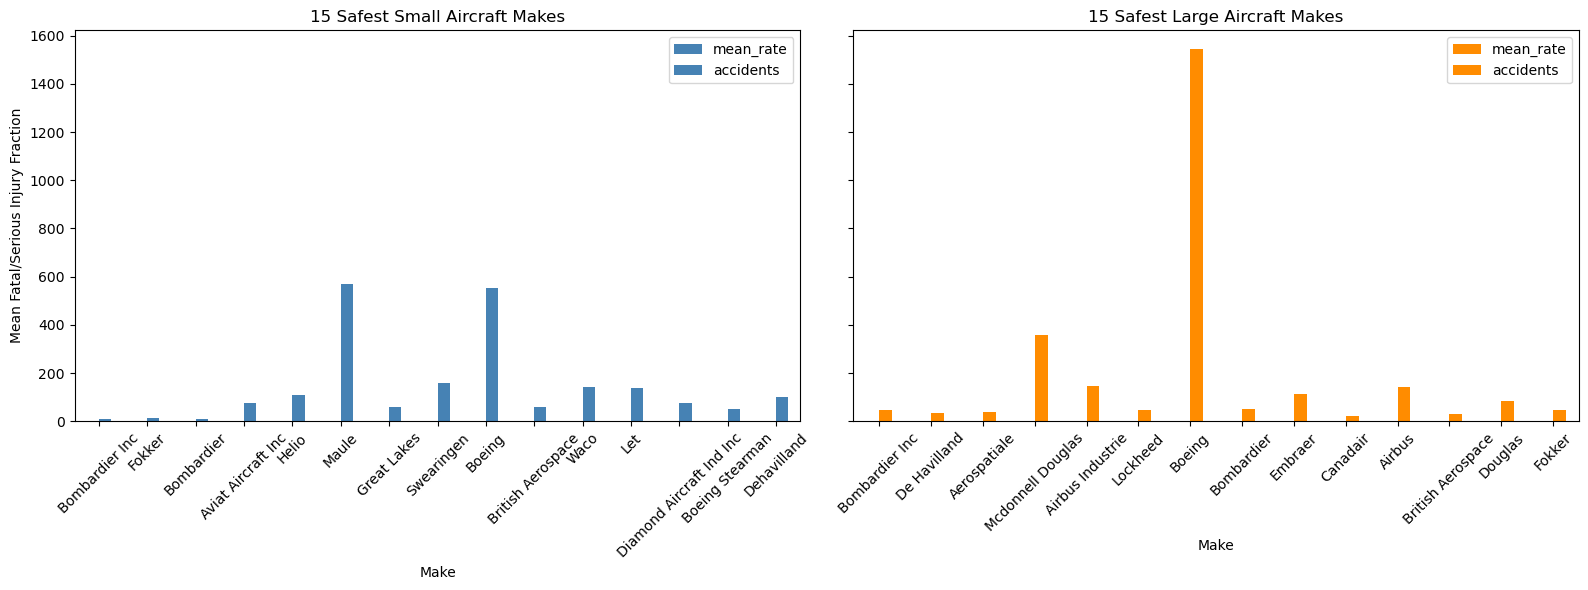

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

small_makes.plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("15 Safest Small Aircraft Makes")
axes[0].set_ylabel("Mean Fatal/Serious Injury Fraction")
axes[0].tick_params(axis="x", rotation=45)

large_makes.plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("15 Safest Large Aircraft Makes")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [64]:
small_df = df[df['aircraft_size'] == 'Small_Plane']

small_stats = (
    small_df.groupby("Make")
    .agg(
        mean_rate=("injury_rate", "mean"),
        accidents=("Make", "size")
    )
)

top10_makes = (
    small_stats[small_stats["accidents"] >= 10]
    .sort_values("mean_rate")
    .head(10)
    .index
)

In [65]:
plot_df = small_df[small_df["Make"].isin(top10_makes)]

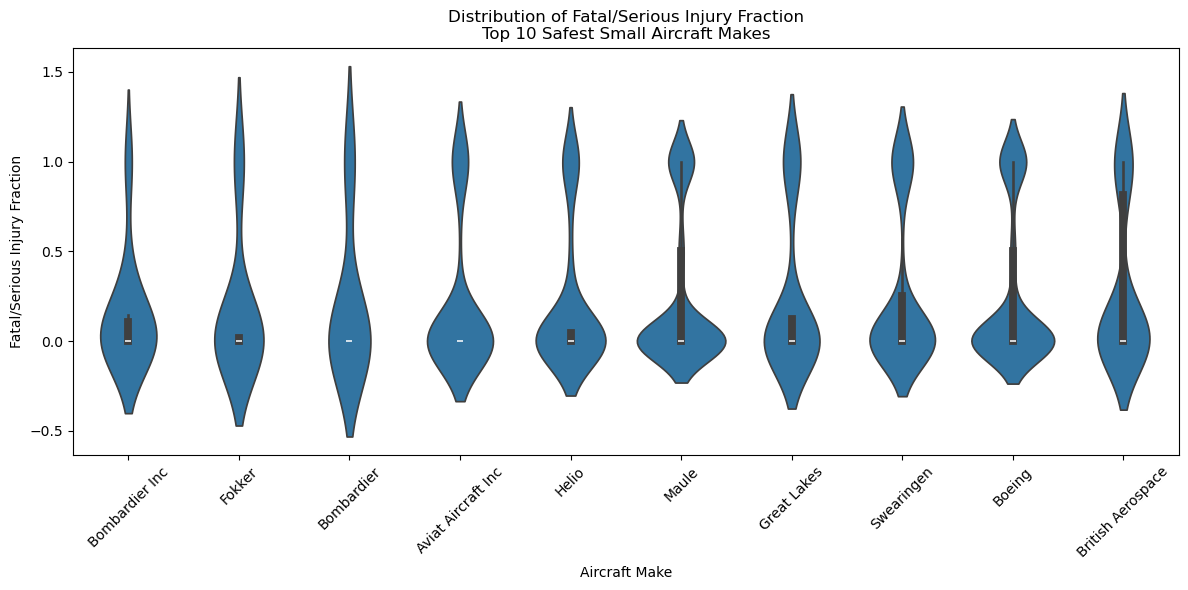

In [66]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=plot_df,
    x="Make",
    y="injury_rate",
    order=top10_makes
)

plt.xticks(rotation=45)
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.title("Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Small Aircraft Makes")

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [67]:
large_df = df[df['aircraft_size'] == 'Large_Plane']

small_stats = (
    large_df.groupby("Make")
    .agg(
        mean_rate=("injury_rate", "mean"),
        accidents=("Make", "size")
    )
)

top10_makes = (
    small_stats[small_stats["accidents"] >= 10]
    .sort_values("mean_rate")
    .head(10)
    .index
)

In [68]:
plot_df = large_df[large_df["Make"].isin(top10_makes)]

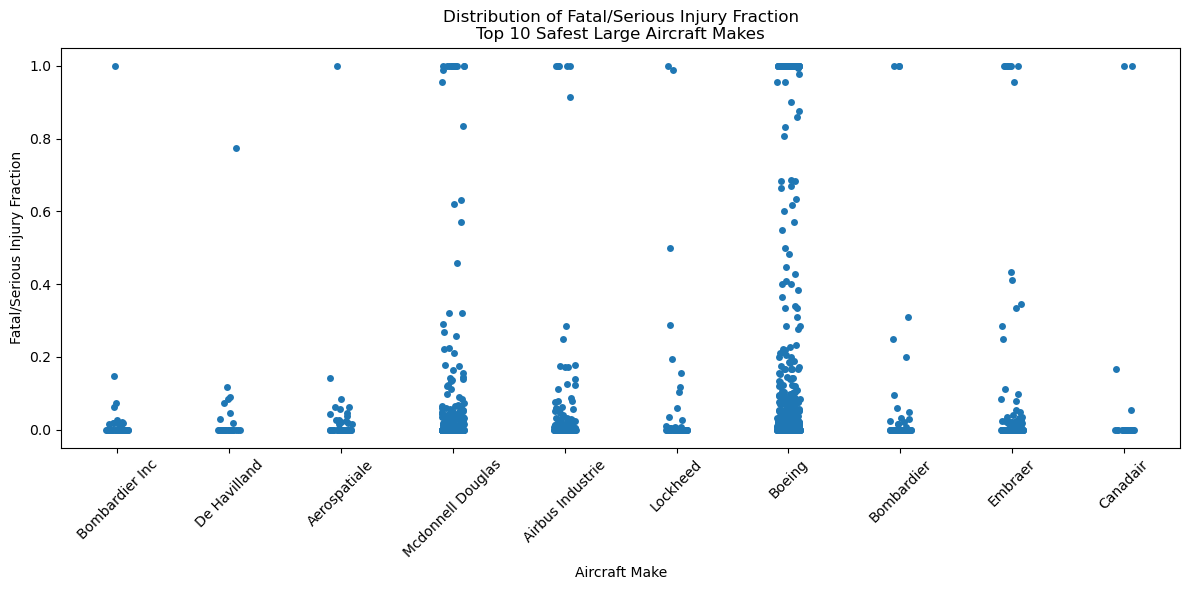

In [69]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=plot_df,
    x="Make",
    y="injury_rate",
    order=top10_makes
)

plt.xticks(rotation=45)
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.title("Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Large Aircraft Makes")

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [70]:
small_df = df[df['aircraft_size'] == 'Small_Plane']
small_destroyed = (
    small_df.groupby("Make")
    .agg(
        destruction_rate=("Aircraft_destroyed", "mean"),
        accidents=("Make", "size")
    )
)

small_destroyed = (
    small_destroyed[small_destroyed["accidents"] >= 10]
    .sort_values("destruction_rate")
    .head(15)
)

print(small_destroyed)

                                destruction_rate  accidents
Make                                                       
Bombardier                              0.000000         10
Grumman Acft Eng Cor-Schweizer          0.017241         58
American Champion Aircraft              0.037037         54
Aviat Aircraft Inc                      0.038961         77
Dehavilland                             0.040000        100
Diamond Aircraft Ind Inc                0.054054         74
Flight Design Gmbh                      0.060000         50
Robinson Helicopter                     0.061135        229
Raven                                   0.063291         79
Balloon Works                           0.064748        139
Let                                     0.080882        136
Fokker                                  0.083333         12
Robinson Helicopter Company             0.083333        192
Waco                                    0.085714        140
Aviat                                   

In [71]:
large_df = df[df['aircraft_size'] == 'Large_Plane']

large_destroyed = (
    large_df.groupby("Make")
    .agg(
        destruction_rate=("Aircraft_destroyed", "mean"),
        accidents=("Make", "size")
    )
)

large_destroyed = (
    large_destroyed[large_destroyed["accidents"] >= 10]
    .sort_values("destruction_rate")
    .head(15)
)

print(large_destroyed)

                   destruction_rate  accidents
Make                                          
Bombardier Inc             0.021739         46
Aerospatiale               0.025641         39
De Havilland               0.028571         35
Mcdonnell Douglas          0.058496        359
Boeing                     0.059547       1545
Embraer                    0.060870        115
Bombardier                 0.061224         49
Airbus Industrie           0.062069        145
Airbus                     0.078571        140
Fokker                     0.083333         48
Lockheed                   0.086957         46
Canadair                   0.095238         21
Douglas                    0.096386         83
British Aerospace          0.100000         30


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [72]:

large_df = df[df['aircraft_size'] == 'Large_Plane']


large_types = (large_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Plane_Type_ID','size')))

large_makes = (large_types[large_types['accidents'] >=10].sort_values('mean_rate').head(10))

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [73]:
small_df = df[df['aircraft_size'] == 'Small_Plane']

small_types = (small_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Plane_Type_ID','size')))

small_makes = (small_types[small_types['accidents'] >=10].sort_values('mean_rate').head(10))


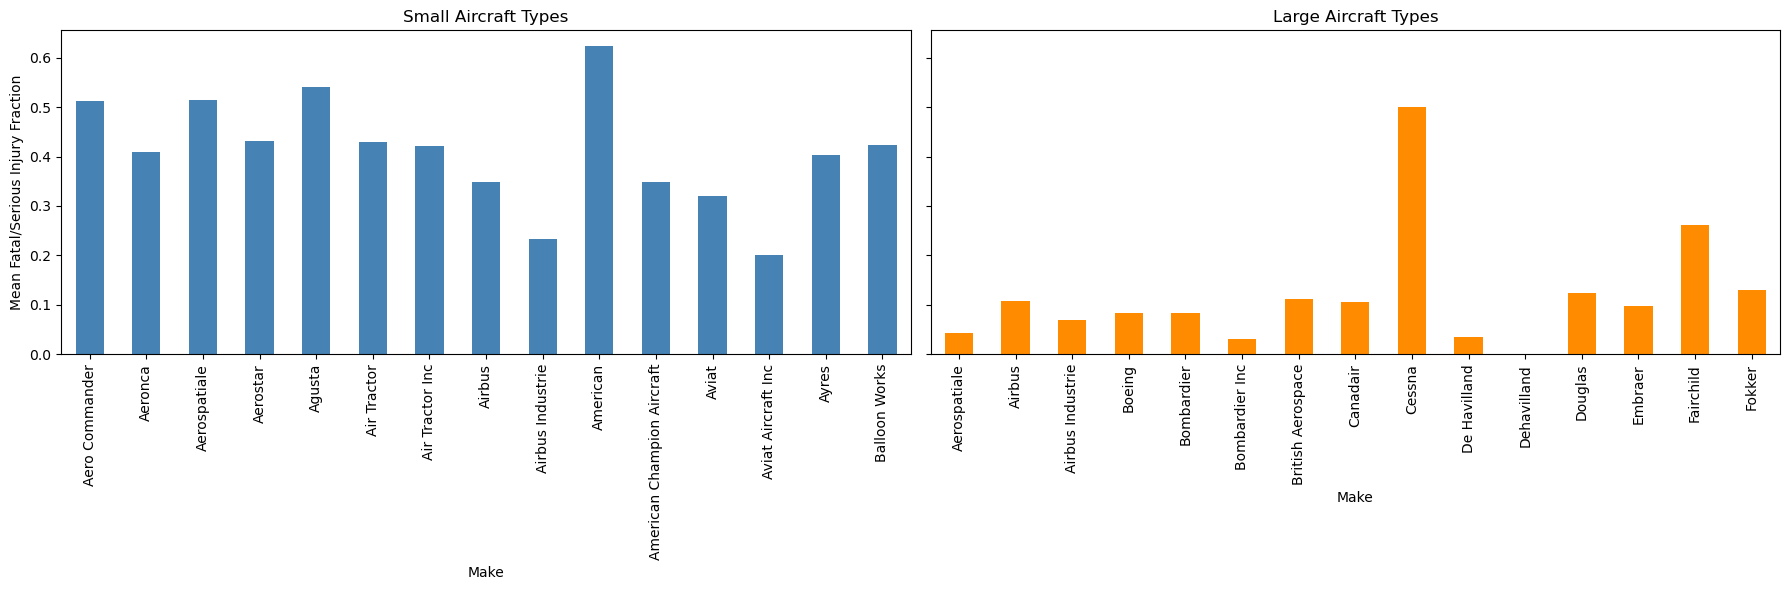

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

small_types.head(15)["mean_rate"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Small Aircraft Types")
axes[0].set_ylabel("Mean Fatal/Serious Injury Fraction")

large_types.head(15)["mean_rate"].plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Large Aircraft Types")

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Number of engines



In [75]:
small_df = df[df['aircraft_size'] == 'Small_Plane']

small_typ = (small_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Number.of.Engines','size')))

small_makes = (small_typ[small_typ['accidents'] >=10].sort_values('mean_rate').head(10))


In [ ]:
large_df = df[df['aircraft_size'] == 'Large_Plane']

large_typ = (large_df.groupby('Make').agg(mean_rate=('injury_rate','mean'),accidents = ('Number.of.Engines','size')))

large_makes = (large_typ[large_typ['accidents'] >=10].sort_values('mean_rate').head(10))

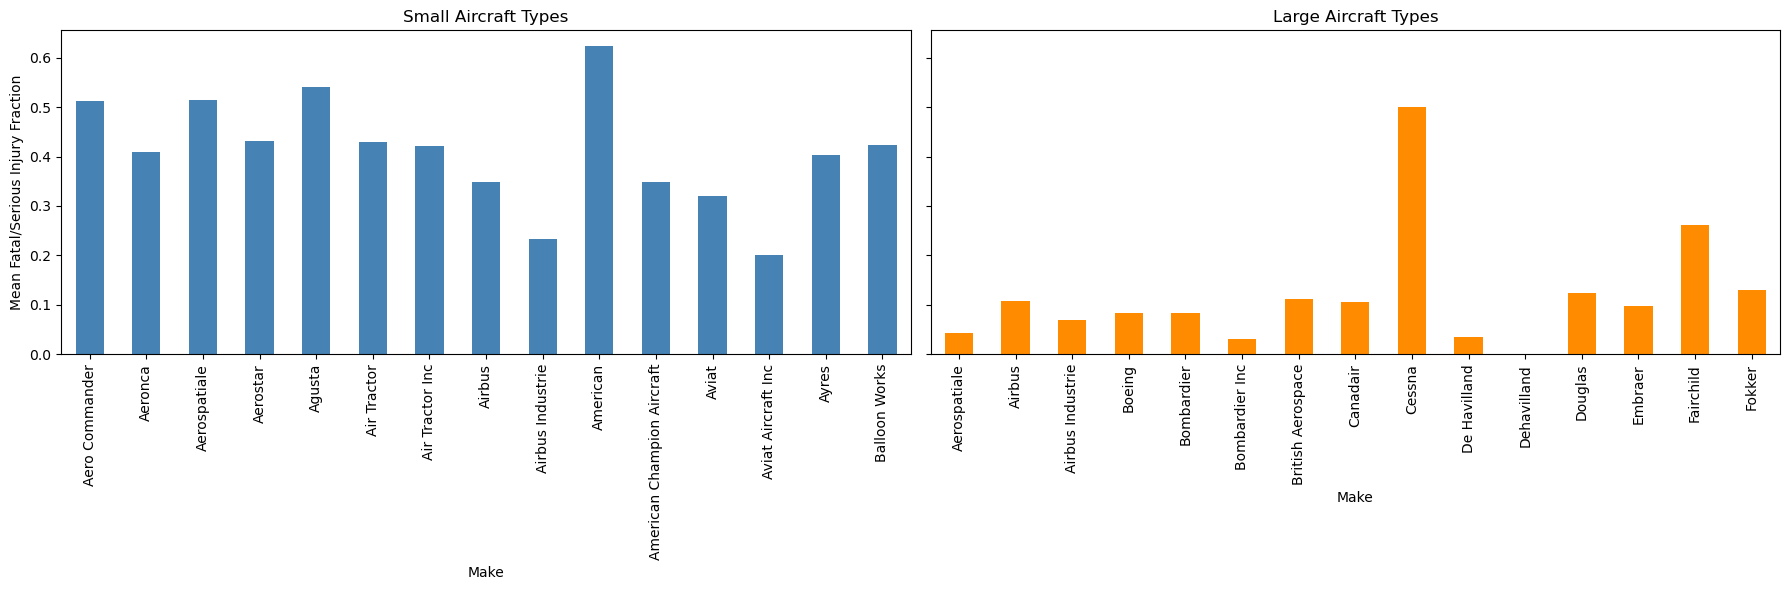

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

small_typ.head(15)["mean_rate"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Small Aircraft Types")
axes[0].set_ylabel("Mean Fatal/Serious Injury Fraction")

large_typ.head(15)["mean_rate"].plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Large Aircraft Types")

plt.tight_layout()
plt.show()